In [8]:
import random
import time
import math

def calculate_pi_serial(num_samples):

    inside_circle = 0

    for _ in range(num_samples):

        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        # Cek apakah titik berada dalam lingkaran
        if x**2 + y**2 <= 1:
            inside_circle += 1

    pi_estimate = 4 * inside_circle / num_samples

    return pi_estimate

# Testing
if __name__ == "__main__":

    num_samples = 10_000_000

    start_time = time.time()

    pi_est = calculate_pi_serial(num_samples)

    end_time = time.time()

    print(f"Estimasi π: {pi_est}")
    print(f"Nilai asli π: {math.pi}")
    print(f"Error: {abs(pi_est - math.pi)}")
    print(f"Waktu eksekusi: {end_time - start_time:.4f} detik")

Estimasi π: 3.1409868
Nilai asli π: 3.141592653589793
Error: 0.0006058535897932593
Waktu eksekusi: 3.1186 detik


In [2]:
import multiprocessing
import random
import time
import math

def monte_carlo_chunk(chunk_size):
    inside = 0

    for _ in range(chunk_size):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        if x**2 + y**2 <= 1:
            inside += 1

    return inside

def calculate_pi_parallel(num_samples, num_processes):

    chunk_size = num_samples // num_processes

    with multiprocessing.Pool(processes=num_processes) as pool:
        results = pool.map(monte_carlo_chunk,
                           [chunk_size] * num_processes)

    total_inside = sum(results)

    pi_estimate = 4 * total_inside / (chunk_size * num_processes)

    return pi_estimate

if __name__ == "__main__":

    num_samples = 10_000_000

    for num_procs in [1, 2, 4, 8, 16, 32]:

        start_time = time.time()

        pi_est = calculate_pi_parallel(
            num_samples,
            num_procs
        )

        end_time = time.time()

        print(f"\nJumlah Process : {num_procs}")
        print(f"Estimasi π : {pi_est}")
        print(f"Waktu : {end_time - start_time:.4f} detik")


Jumlah Process : 1
Estimasi π : 3.1415536
Waktu : 4.2571 detik

Jumlah Process : 2
Estimasi π : 3.141392
Waktu : 2.8799 detik

Jumlah Process : 4
Estimasi π : 3.1416364
Waktu : 1.9114 detik

Jumlah Process : 8
Estimasi π : 3.139818
Waktu : 1.2646 detik

Jumlah Process : 16
Estimasi π : 3.1413348
Waktu : 1.0688 detik

Jumlah Process : 32
Estimasi π : 3.1414
Waktu : 1.7143 detik


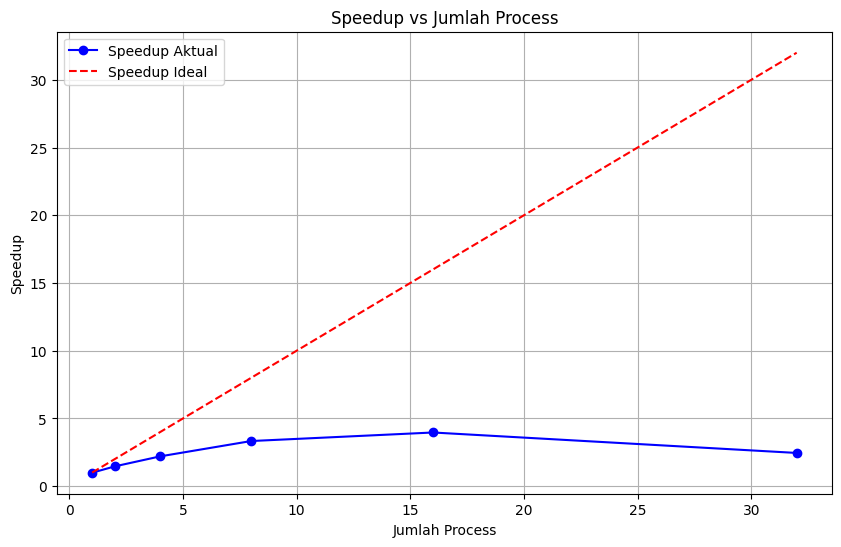

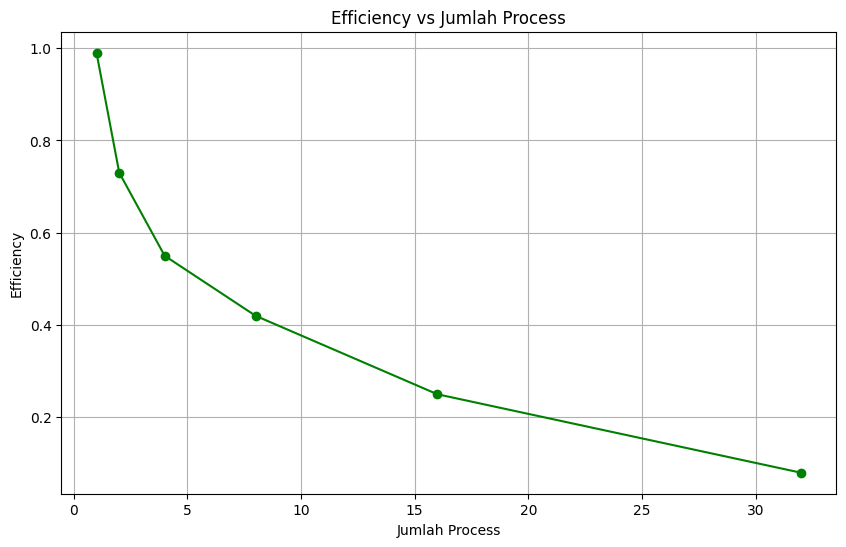

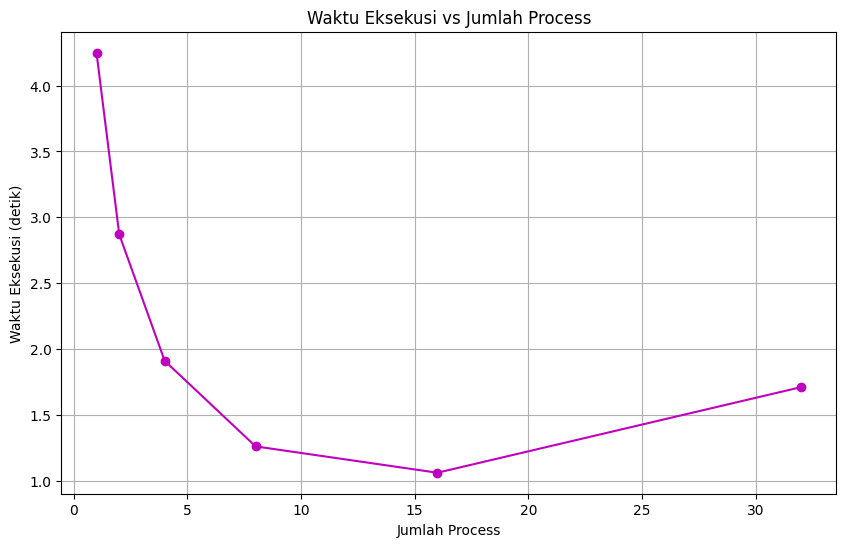

In [4]:
import matplotlib.pyplot as plt

process_counts = [1, 2, 4, 8, 16, 32]

speedups = [0.99, 1.46, 2.20, 3.33, 3.96, 2.45]

efficiency = [0.99, 0.73, 0.55, 0.42, 0.25, 0.08]

execution_time = [4.25, 2.87, 1.91, 1.26, 1.06, 1.71]

# Grafik Speedup
plt.figure(figsize=(10,6))

plt.plot(process_counts,
         speedups,
         'bo-',
         label='Speedup Aktual')

plt.plot(process_counts,
         process_counts,
         'r--',
         label='Speedup Ideal')

plt.xlabel('Jumlah Process')
plt.ylabel('Speedup')
plt.title('Speedup vs Jumlah Process')

plt.legend()
plt.grid(True)

plt.show()

# Grafik Efficiency
plt.figure(figsize=(10,6))

plt.plot(process_counts,
         efficiency,
         'go-')

plt.xlabel('Jumlah Process')
plt.ylabel('Efficiency')
plt.title('Efficiency vs Jumlah Process')

plt.grid(True)

plt.show()

# Grafik Waktu Eksekusi
plt.figure(figsize=(10,6))

plt.plot(process_counts,
         execution_time,
         'mo-')

plt.xlabel('Jumlah Process')
plt.ylabel('Waktu Eksekusi (detik)')
plt.title('Waktu Eksekusi vs Jumlah Process')

plt.grid(True)

plt.show()